In [2]:
import numpy as np
import pandas as pd
import rasterio
from scipy.ndimage import label, generate_binary_structure

mask_path = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/thesis/data/raw/sasovske_mask.tif"
pred_path = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/thesis/v3+_shadowed_sasovske_512_128_predictions_map.tif"

#mask = np.load(mask_path)
with rasterio.open(mask_path) as src:
    mask = src.read(1)
    transform = src.transform
    pixel_area_m2 = abs(transform.a * transform.e)

mask = np.squeeze(mask)
gt = mask > 0

with rasterio.open(pred_path) as src:
    pred = src.read(1)
    transform = src.transform
    pixel_area_m2 = abs(transform.a * transform.e)

pred = np.squeeze(pred)
pred_bin = pred > 0

pred_bin = np.zeros(shape=gt.shape,dtype=bool)

print("GT shape:", gt.shape)
print("Prediction shape:", pred_bin.shape)
print("Pixel area [m²]:", pixel_area_m2)

if gt.shape != pred_bin.shape:
    raise ValueError(
        f"Shape mismatch: GT {gt.shape} vs prediction {pred_bin.shape}. "
        "Cannot compute object-level hit rate without spatial alignment."
    )

structure = generate_binary_structure(2, 2)
gt_labels, num_gt_objects = label(gt, structure=structure)

object_sizes_px = np.bincount(gt_labels.ravel())[1:]
object_areas_m2 = object_sizes_px * pixel_area_m2

categories = np.full(num_gt_objects, "large", dtype=object)
categories[object_areas_m2 < 50] = "small"
categories[(object_areas_m2 >= 50) & (object_areas_m2 <= 200)] = "medium"

overlap_labels = gt_labels[pred_bin]
overlap_counts = np.bincount(overlap_labels, minlength=num_gt_objects + 1)[1:]

min_overlap_pixels = 1
hit = overlap_counts >= min_overlap_pixels

objects_df = pd.DataFrame({
    "object_id": np.arange(1, num_gt_objects + 1),
    "area_px": object_sizes_px,
    "area_m2": object_areas_m2,
    "category": categories,
    "overlap_px": overlap_counts,
    "hit": hit
})

summary_df = (
    objects_df
    .groupby("category")
    .agg(
        total_objects=("object_id", "count"),
        hit_objects=("hit", "sum"),
        mean_area_m2=("area_m2", "mean"),
        median_area_m2=("area_m2", "median"),
        min_area_m2=("area_m2", "min"),
        max_area_m2=("area_m2", "max"),
        total_area_m2=("area_m2", "sum")
    )
    .reset_index()
)

total_objects_all = len(objects_df)
map_area_m2 = gt.shape[0] * gt.shape[1] * pixel_area_m2

summary_df["objects_percent"] = (
    summary_df["total_objects"] / total_objects_all * 100
)

summary_df["map_area_percent"] = (
    summary_df["total_area_m2"] / map_area_m2 * 100
)

summary_df["objects_percent"] = summary_df["objects_percent"].round(2)
summary_df["map_area_percent"] = summary_df["map_area_percent"].round(4)
summary_df["total_area_m2"] = summary_df["total_area_m2"].round(2)

summary_df["hit_rate"] = summary_df["hit_objects"] / summary_df["total_objects"]

category_order = pd.CategoricalDtype(["small", "medium", "large"], ordered=True)
summary_df["category"] = summary_df["category"].astype(category_order)
summary_df = summary_df.sort_values("category").reset_index(drop=True)

total_summary = pd.DataFrame({
    "category": ["all"],
    "total_objects": [len(objects_df)],
    "hit_objects": [objects_df["hit"].sum()],
    "mean_area_m2": [objects_df["area_m2"].mean()],
    "median_area_m2": [objects_df["area_m2"].median()],
    "min_area_m2": [objects_df["area_m2"].min()],
    "max_area_m2": [objects_df["area_m2"].max()],
    "hit_rate": [objects_df["hit"].mean()],
})

summary_df = pd.concat([summary_df, total_summary], ignore_index=True)

print("Total GT objects:", num_gt_objects)
display(summary_df)

GT shape: (2799, 3180)
Prediction shape: (2799, 3180)
Pixel area [m²]: 0.0625
Total GT objects: 91


,category,total_objects,hit_objects,mean_area_m2,median_area_m2,min_area_m2,max_area_m2,total_area_m2,objects_percent,map_area_percent,hit_rate
0,small,12,0,40.557292,41.37500,33.9375,45.5000,486.69,13.19,0.0875,0.0
1,medium,59,0,97.809322,89.56250,52.8125,199.6875,5770.75,64.84,1.0373,0.0
2,large,20,0,272.771875,250.53125,205.0625,434.3750,5455.44,21.98,0.9807,0.0
3,all,91,0,128.712912,94.62500,33.9375,434.3750,NaN,NaN,NaN,0.0


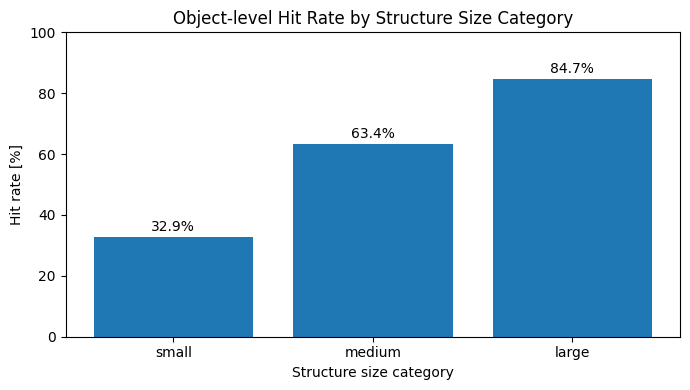

In [6]:
import matplotlib.pyplot as plt

plot_df = summary_df[summary_df["category"] != "all"].copy()
plot_df["hit_rate_percent"] = plot_df["hit_rate"] * 100

plt.figure(figsize=(7, 4))

bars = plt.bar(
    plot_df["category"].astype(str),
    plot_df["hit_rate_percent"]
)

plt.ylim(0, 100)
plt.xlabel("Structure size category")
plt.ylabel("Hit rate [%]")
plt.title("Object-level Hit Rate by Structure Size Category")

for bar, value in zip(bars, plot_df["hit_rate_percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()